### Data Preprocessing

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/egypt_enhanced_electricity_dataset.csv')

print('Dataset loaded successfully!')

Dataset loaded successfully!


#### Displaying Basic Information

In [ ]:
# Display the first 5 rows
print('First 5 rows of the dataset:')
display(df.head())

# Display concise summary of the DataFrame
print('\nDataFrame Info:')
df.info()

# Display descriptive statistics
print('\nDescriptive Statistics:')
display(df.describe())

First 5 rows of the dataset:


,AC_units,fridge_count,TV_count,fans_count,PC_count,avg_usage_hours,monthly_kwh,electricity_bill_EGP
0,3,1,2,1,2,4,31.80,18.44
1,0,1,3,3,0,8,22.36,12.97
2,1,1,1,3,2,4,26.38,15.30
3,3,1,2,3,0,6,51.12,34.76
4,1,1,3,3,0,7,32.75,18.99



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AC_units              500 non-null    int64  
 1   fridge_count          500 non-null    int64  
 2   TV_count              500 non-null    int64  
 3   fans_count            500 non-null    int64  
 4   PC_count              500 non-null    int64  
 5   avg_usage_hours       500 non-null    int64  
 6   monthly_kwh           500 non-null    float64
 7   electricity_bill_EGP  500 non-null    float64
dtypes: float64(2), int64(6)
memory usage: 31.4 KB

Descriptive Statistics:


,AC_units,fridge_count,TV_count,fans_count,PC_count,avg_usage_hours,monthly_kwh,electricity_bill_EGP
count,500.000000,500.0,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,1.486000,1.0,1.970000,2.480000,0.920000,8.314000,43.717420,28.35574
std,1.099191,0.0,0.811429,1.677865,0.821553,3.635083,25.021643,19.59007
min,0.000000,1.0,1.000000,0.000000,0.000000,2.000000,9.940000,5.77000
25%,1.000000,1.0,1.000000,1.000000,0.000000,5.000000,24.192500,14.03250
50%,2.000000,1.0,2.000000,2.000000,1.000000,8.000000,37.840000,21.95000
75%,2.000000,1.0,3.000000,4.000000,2.000000,11.000000,58.457500,39.75500
max,3.000000,1.0,3.000000,5.000000,2.000000,14.000000,132.270000,109.78000


#### Checking and Handling Missing Values

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
display(missing_values[missing_values > 0])

# Handle missing values (if any) - Impute with mean for numerical columns
for col in df.columns:
    if df[col].isnull().any() and pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())
        print(f"Filled missing values in '{col}' with its mean.")

# Verify no more missing values
print('\nMissing values after handling:')
display(df.isnull().sum()[df.isnull().sum() > 0])

Missing values in each column:


,0



Missing values after handling:


,0


#### Checking for Outliers

We can use box plots to visualize outliers in numerical columns. Handling outliers often depends on the context of the data and the specific model being used. Common strategies include capping (winsorization), transformation, or removal.

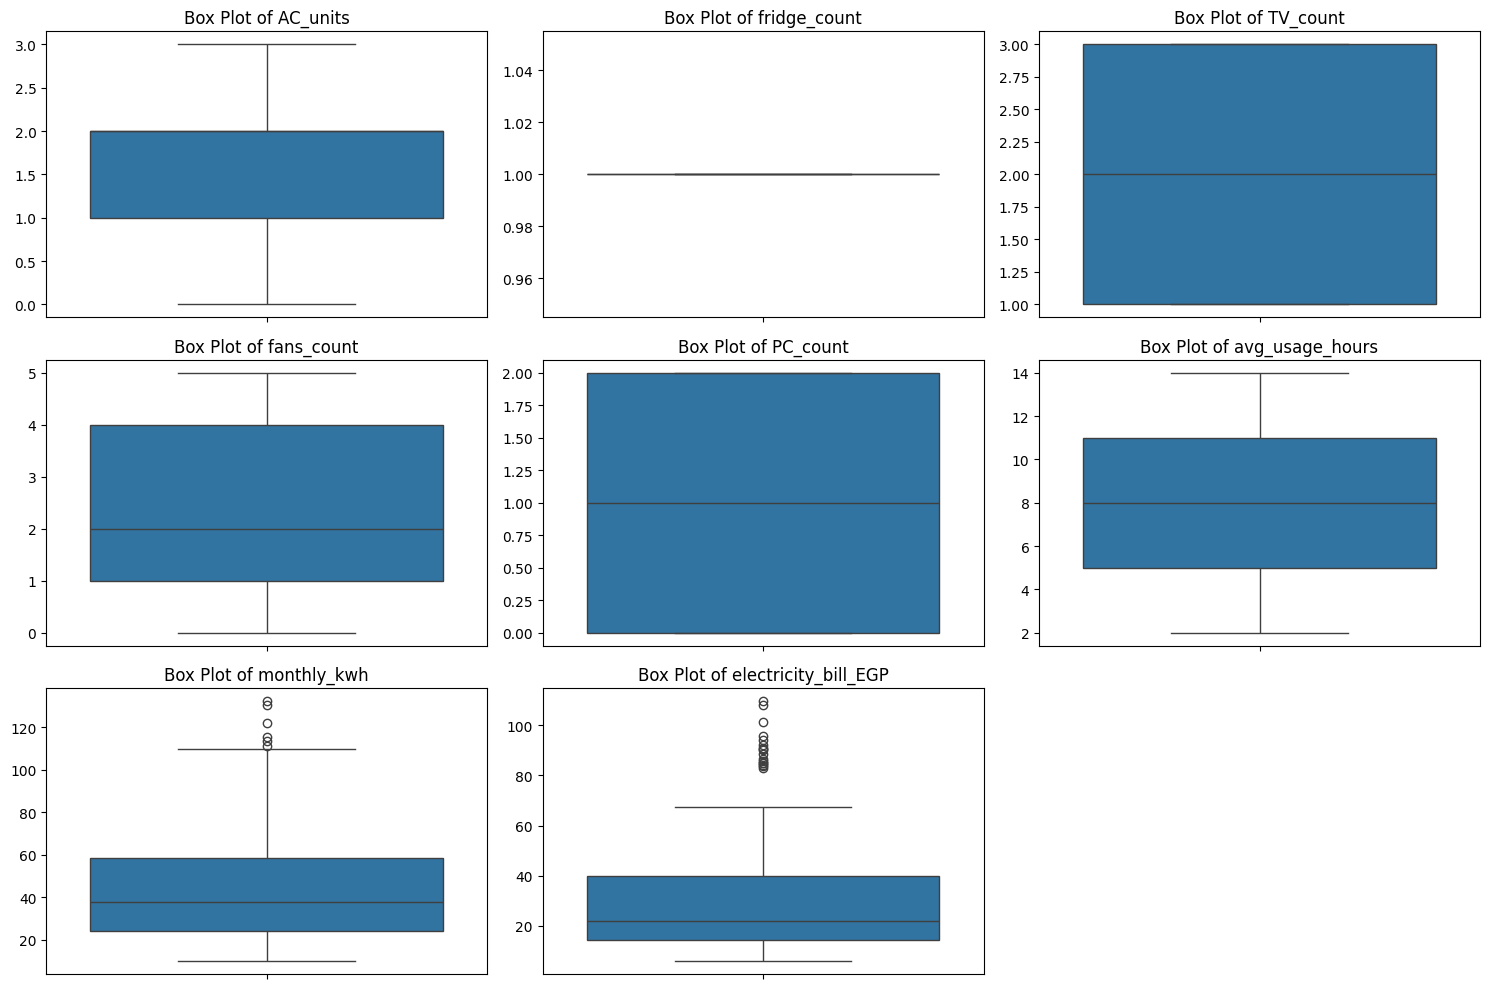

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Exclude the target variable if it's already identified and we want to check features
# For now, let's check all numerical columns.

# Plot box plots for numerical columns to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

#### Normalizing/Scaling Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('electricity_bill_EGP', axis=1)
y = df['electricity_bill_EGP']

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features in X
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Features scaled successfully using StandardScaler.')
print('\nFirst 5 rows of scaled features:')
display(X_scaled.head())

Features scaled successfully using StandardScaler.

First 5 rows of scaled features:


,AC_units,fridge_count,TV_count,fans_count,PC_count,avg_usage_hours,monthly_kwh
0,1.378756,0.0,0.037009,-0.882957,1.315899,-1.187956,-0.476761
1,-1.353258,0.0,1.270637,0.310228,-1.120951,-0.086467,-0.854413
2,-0.442586,0.0,-1.196619,0.310228,1.315899,-1.187956,-0.693591
3,1.378756,0.0,0.037009,0.310228,-1.120951,-0.637212,0.296143
4,-0.442586,0.0,1.270637,0.310228,-1.120951,-0.361839,-0.438756


#### Splitting into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f'Original dataset shape: {df.shape}')
print(f'Training features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')
print(f'Training target shape: {y_train.shape}')
print(f'Testing target shape: {y_test.shape}')

print('\nData splitting complete. X_train, X_test, y_train, y_test are ready for model training.')

Original dataset shape: (500, 8)
Training features shape: (400, 7)
Testing features shape: (100, 7)
Training target shape: (400,)
Testing target shape: (100,)

Data splitting complete. X_train, X_test, y_train, y_test are ready for model training.


### Machine Learning Model: Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print('Linear Regression model trained successfully!')

Linear Regression model trained successfully!


#### Evaluate Linear Regression Model

In [ ]:
# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression MAE: {mae_lr:.2f}')
print(f'Linear Regression MSE: {mse_lr:.2f}')
print(f'Linear Regression R² Score: {r2_lr:.2f}')

Linear Regression MAE: 1.65
Linear Regression MSE: 5.38
Linear Regression R² Score: 0.98


#### Print Feature Importance (Coefficients) for Linear Regression

In [ ]:
# Get feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
feature_importance_lr['Absolute_Coefficient'] = abs(feature_importance_lr['Coefficient'])
feature_importance_lr = feature_importance_lr.sort_values(by='Absolute_Coefficient', ascending=False)

print('\nFeature Importance (Linear Regression - sorted by absolute value):')
display(feature_importance_lr)


Feature Importance (Linear Regression - sorted by absolute value):


,Feature,Coefficient,Absolute_Coefficient
6,monthly_kwh,2.211205e+01,2.211205e+01
0,AC_units,-2.164221e+00,2.164221e+00
5,avg_usage_hours,-1.667713e+00,1.667713e+00
4,PC_count,-5.136488e-01,5.136488e-01
2,TV_count,-3.775818e-01,3.775818e-01
3,fans_count,-1.510774e-01,1.510774e-01
1,fridge_count,3.552714e-15,3.552714e-15


### Deep Learning Model: Neural Network

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build a simple Neural Network model
# Input layer: matches the number of features in X_train
# Hidden layers: at least 2 hidden layers with ReLU activation
# Output layer: single unit for regression task

n_features = X_train.shape[1]

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(n_features,), name='Input_Layer'),
    layers.Dense(64, activation='relu', name='Hidden_Layer_1'),
    layers.Dense(32, activation='relu', name='Hidden_Layer_2'),
    layers.Dense(1, name='Output_Layer') # Output layer for regression
])

# Compile the model
# Optimizer: Adam, Loss: Mean Squared Error
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()
print('\nNeural Network model built and compiled successfully!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (Dense)             │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)


Neural Network model built and compiled successfully!


#### Train the Neural Network Model

In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100, # Number of training iterations
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data for validation during training
    verbose=0 # Suppress verbose output during training
)

print('\nNeural Network model trained successfully!')


Neural Network model trained successfully!


#### Evaluate the Neural Network Model on Test Data

In [ ]:
# Evaluate the model on the test data
loss_nn = model.evaluate(X_test, y_test, verbose=0)
print(f'Neural Network Test Loss (MSE): {loss_nn:.2f}')

# Make predictions for R² and other metrics
y_pred_nn = model.predict(X_test).flatten()

mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f'Neural Network MAE: {mae_nn:.2f}')
print(f'Neural Network MSE: {mse_nn:.2f}')
print(f'Neural Network R² Score: {r2_nn:.2f}')

Neural Network Test Loss (MSE): 4.51
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Neural Network MAE: 1.41
Neural Network MSE: 4.51
Neural Network R² Score: 0.98


### Visualization

#### Plot: Actual vs Predicted Values

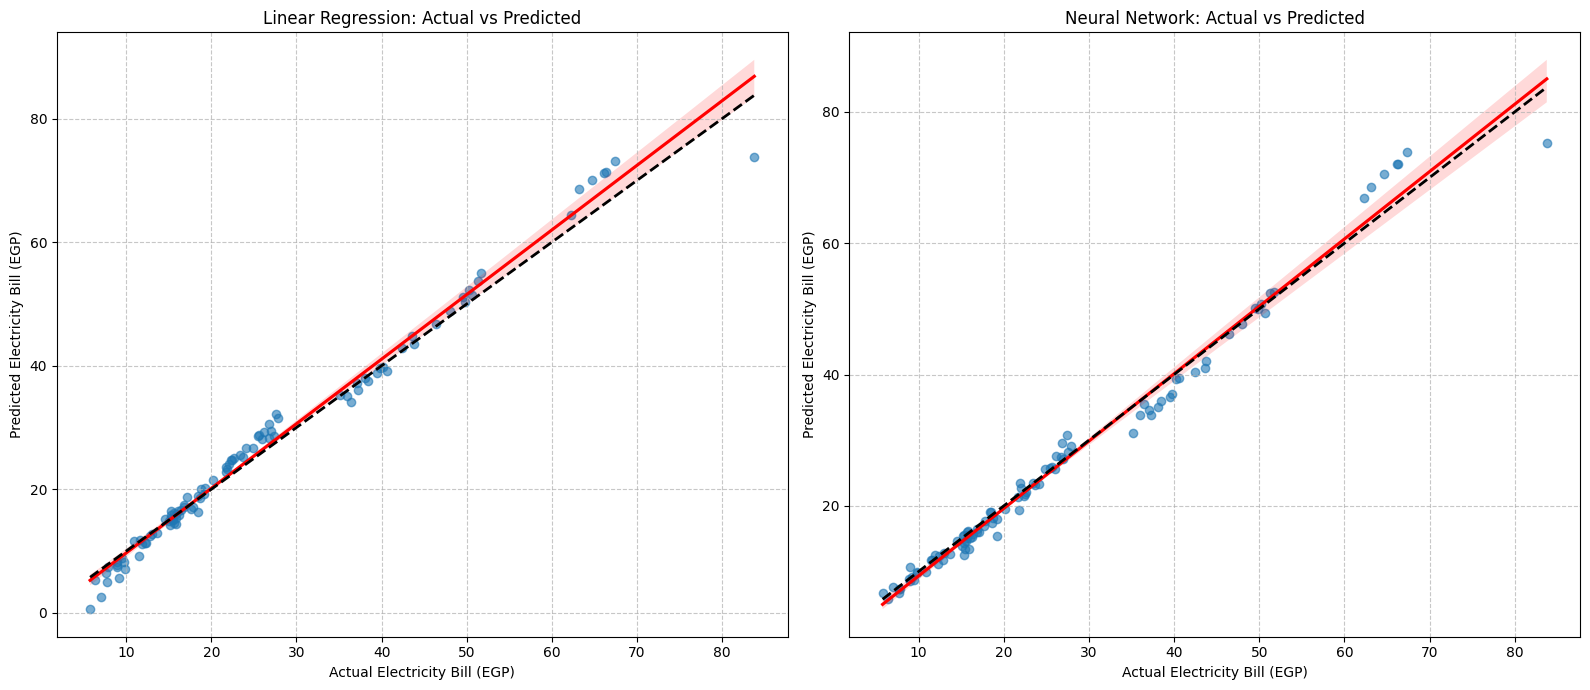

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 7))

# Plot for Linear Regression
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.regplot(x=y_test, y=y_pred_lr, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ideal line
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Electricity Bill (EGP)')
plt.ylabel('Predicted Electricity Bill (EGP)')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot for Neural Network
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.regplot(x=y_test, y=y_pred_nn, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ideal line
plt.title('Neural Network: Actual vs Predicted')
plt.xlabel('Actual Electricity Bill (EGP)')
plt.ylabel('Predicted Electricity Bill (EGP)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot: Loss Curve for DL Model

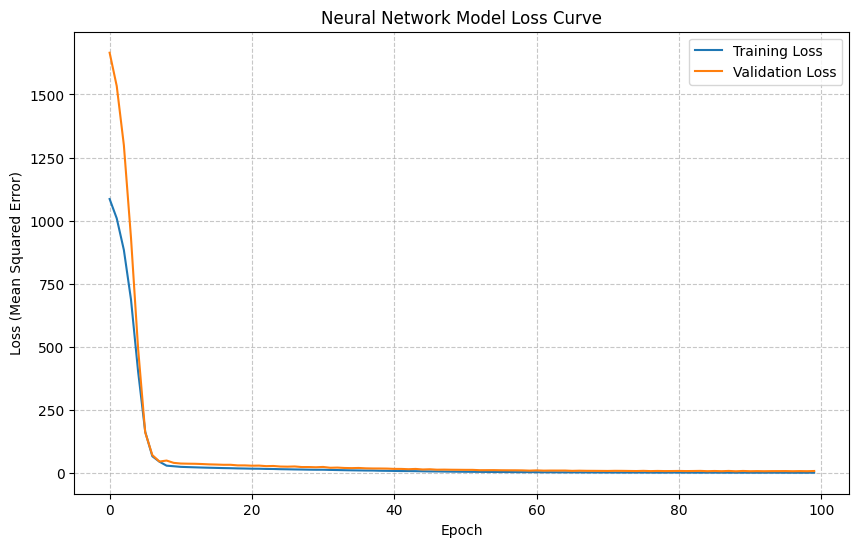

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Model Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Bonus: Model Comparison and Suggestion

In [ ]:
print('--- Model Performance Comparison ---')
print(f'\nLinear Regression:')
print(f'  MAE: {mae_lr:.2f}')
print(f'  MSE: {mse_lr:.2f}')
print(f'  R² Score: {r2_lr:.2f}')

print(f'\nNeural Network:')
print(f'  MAE: {mae_nn:.2f}')
print(f'  MSE: {mse_nn:.2f}')
print(f'  R² Score: {r2_nn:.2f}')

print('\n--- Conclusion ---')
if r2_nn > r2_lr:
    print('The Neural Network model generally performs better than the Linear Regression model.')
    print('This is indicated by its higher R² Score and potentially lower MAE/MSE,')
    print('suggesting it captures more of the variance in the target variable.')
    print('Neural Networks are often better at modeling complex, non-linear relationships in data.')
else:
    print('The Linear Regression model generally performs better than or comparably to the Neural Network model.')
    print('This is indicated by its higher R² Score or similar MAE/MSE.')
    print('In cases where Linear Regression performs well, it implies that the relationship')
    print('between features and target is relatively linear or simpler, and a simpler model')
    print('is sufficient. Linear Regression is also more interpretable due to its coefficients.')

--- Model Performance Comparison ---

Linear Regression:
  MAE: 1.65
  MSE: 5.38
  R² Score: 0.98

Neural Network:
  MAE: 1.41
  MSE: 4.51
  R² Score: 0.98

--- Conclusion ---
The Neural Network model generally performs better than the Linear Regression model.
This is indicated by its higher R² Score and potentially lower MAE/MSE,
suggesting it captures more of the variance in the target variable.
Neural Networks are often better at modeling complex, non-linear relationships in data.


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Number of rows
n = 30000

# -----------------------------
# 1. Generate basic features
# -----------------------------
AC_units = np.random.randint(0, 5, n)
fridge_count = np.random.randint(1, 3, n)
TV_count = np.random.randint(0, 4, n)
fans_count = np.random.randint(0, 5, n)
PC_count = np.random.randint(0, 3, n)

avg_usage_hours = np.random.uniform(3, 10, n)

# AC power (HP)
ac_power_hp = np.round(np.random.choice([1.5, 2.25, 3], n), 2)

# Season effect
season = np.random.choice(["winter", "summer"], n)
season_factor = np.where(season == "summer", 1.5, 0.8)

# House size (correlated with AC units)
house_size_m2 = np.clip(AC_units * 40 + np.random.normal(50, 20, n), 50, 300)

# Insulation quality
insulation_quality = np.random.choice(["low", "medium", "high"], n)
insulation_factor = np.select(
    [insulation_quality == "low",
     insulation_quality == "medium",
     insulation_quality == "high"],
    [1.3, 1.0, 0.8]
)

# Water heater
has_water_heater = np.random.choice([0, 1], n)
heater_usage = has_water_heater * np.random.uniform(1, 3, n)

# Washing machine usage
washing_per_week = np.random.randint(0, 7, n)

# -----------------------------
# 2. Calculate monthly kWh
# -----------------------------
monthly_kwh = (
    AC_units * ac_power_hp * avg_usage_hours * season_factor * insulation_factor * 30 +
    fridge_count * 1.2 * 24 * 30 +
    TV_count * 0.1 * avg_usage_hours * 30 +
    fans_count * 0.075 * avg_usage_hours * 30 +
    PC_count * 0.2 * avg_usage_hours * 30 +
    heater_usage * 3 * 30 +
    washing_per_week * 0.5 * 4
)

# Add noise
monthly_kwh += np.random.normal(0, 10, n)

# Ensure no negative values
monthly_kwh = np.clip(monthly_kwh, 20, None)

# -----------------------------
# 3. Egyptian electricity tariff
# -----------------------------
def calculate_bill(kwh):
    if kwh <= 50:
        return kwh * 0.48
    elif kwh <= 100:
        return 50*0.48 + (kwh-50)*0.58
    elif kwh <= 200:
        return 50*0.48 + 50*0.58 + (kwh-100)*0.77
    elif kwh <= 350:
        return 50*0.48 + 50*0.58 + 100*0.77 + (kwh-200)*1.06
    else:
        return kwh * 1.20

electricity_bill = np.array([calculate_bill(k) for k in monthly_kwh])

# Add small billing noise
electricity_bill += np.random.normal(0, 5, n)

# -----------------------------
# 4. Create DataFrame
# -----------------------------
df = pd.DataFrame({
    "number_of_air_conditioners": AC_units,
    "ac_power_hp": ac_power_hp,
    "number_of_refrigerators": fridge_count,
    "number_of_televisions": TV_count,
    "number_of_fans": fans_count,
    "number_of_computers": PC_count,
    "average_daily_usage_hours": avg_usage_hours,
    "season": season,
    "house_size_m2": house_size_m2,
    "insulation_quality": insulation_quality,
    "has_water_heater": has_water_heater,
    "washing_machine_usage_per_week": washing_per_week,
    "monthly_energy_consumption_kwh": monthly_kwh,
    "monthly_electricity_bill_egp": electricity_bill
})

# -----------------------------
# 5. Save dataset
# -----------------------------
df.to_csv("realistic_egypt_electricity_dataset.csv", index=False)

print("Dataset generated successfully with shape:", df.shape)
print(df.head())

Dataset generated successfully with shape: (30000, 14)
   number_of_air_conditioners  ac_power_hp  number_of_refrigerators  \
0                           3         1.50                        2   
1                           4         1.50                        2   
2                           2         1.50                        2   
3                           4         3.00                        2   
4                           4         2.25                        2   

   number_of_televisions  number_of_fans  number_of_computers  \
0                      2               2                    0   
1                      3               4                    0   
2                      1               0                    1   
3                      1               3                    1   
4                      0               3                    0   

   average_daily_usage_hours  season  house_size_m2 insulation_quality  \
0                   5.892710  summer     164.957496  

# **New Start**

# Dataset Description

This dataset represents household electricity consumption in Egypt and is designed to support machine learning models for predicting energy usage and electricity bills.

Each record corresponds to a single household and includes information about:

The number and type of electrical appliances (such as air conditioners, refrigerators, TVs, fans, and computers)
Usage behavior (average daily usage hours)
Environmental and structural factors (season, house size, insulation quality)
Additional energy-consuming activities (water heater usage and washing machine frequency)

The dataset also includes:

Monthly energy consumption (kWh), calculated based on realistic appliance usage patterns
Monthly electricity bill (EGP), computed using a tiered pricing system similar to real-world Egyptian electricity tariffs

To enhance realism, the dataset incorporates:

Variability in user behavior
Correlations between features (e.g., larger homes tend to have more air conditioners)
Random noise to simulate real-world measurement and billing variations

This dataset can be used for:

Predicting electricity consumption or cost (regression tasks)
Analyzing the impact of different appliances on energy usage
Developing smart energy management or recommendation systems

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the new dataset, overwriting the previous df
df = pd.read_csv('/content/realistic_egypt_electricity_dataset.csv')
print("New dataset 'realistic_egypt_electricity_dataset.csv' loaded successfully!")

# Handle categorical features using one-hot encoding
# The new dataset has 'season' and 'insulation_quality' as categorical
df = pd.get_dummies(df, columns=['season', 'insulation_quality'], drop_first=True)
print("Categorical features 'season' and 'insulation_quality' one-hot encoded.")

# Check for missing values and handle them (though the generated dataset should be clean)
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Imputing with mean for numerical columns.")
    for col in df.columns:
        if df[col].isnull().any() and pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].mean())
else:
    print("No missing values found in the new dataset.")

New dataset 'realistic_egypt_electricity_dataset.csv' loaded successfully!
Categorical features 'season' and 'insulation_quality' one-hot encoded.
No missing values found in the new dataset.


#### Basic Information After Preprocessing (before feature scaling)

In [ ]:
print('DataFrame Info after one-hot encoding:')
df.info()

print('\nDescriptive Statistics after one-hot encoding:')
display(df.describe())

DataFrame Info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   number_of_air_conditioners      30000 non-null  int64  
 1   ac_power_hp                     30000 non-null  float64
 2   number_of_refrigerators         30000 non-null  int64  
 3   number_of_televisions           30000 non-null  int64  
 4   number_of_fans                  30000 non-null  int64  
 5   number_of_computers             30000 non-null  int64  
 6   average_daily_usage_hours       30000 non-null  float64
 7   house_size_m2                   30000 non-null  float64
 8   has_water_heater                30000 non-null  int64  
 9   washing_machine_usage_per_week  30000 non-null  int64  
 10  monthly_energy_consumption_kwh  30000 non-null  float64
 11  monthly_electricity_bill_egp    30000 non-null  float6

,number_of_air_conditioners,ac_power_hp,number_of_refrigerators,number_of_televisions,number_of_fans,number_of_computers,average_daily_usage_hours,house_size_m2,has_water_heater,washing_machine_usage_per_week,monthly_energy_consumption_kwh,monthly_electricity_bill_egp
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2.011767,2.248525,1.505733,1.492500,1.994800,1.000267,6.486696,132.154005,0.498800,3.013300,2541.189301,3049.370678
std,1.420456,0.611967,0.499975,1.119487,1.419169,0.817612,2.018810,57.707102,0.500007,1.994506,1149.422924,1379.309015
min,0.000000,1.500000,1.000000,0.000000,0.000000,0.000000,3.000193,50.000000,0.000000,0.000000,844.602108,1015.073419
25%,1.000000,1.500000,1.000000,0.000000,1.000000,0.000000,4.731624,80.390089,0.000000,1.000000,1787.513056,2144.661462
50%,2.000000,2.250000,2.000000,1.000000,2.000000,1.000000,6.482449,129.997519,0.000000,3.000000,2335.628079,2803.264448
75%,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,8.228731,181.518209,1.000000,5.000000,3107.203300,3728.272839
max,4.000000,3.000000,2.000000,3.000000,4.000000,2.000000,9.999449,284.158104,1.000000,6.000000,9000.498075,10804.421551


In [ ]:
# Define features (X) and target (y), overwriting previous X and y
X = df.drop('monthly_electricity_bill_egp', axis=1)
y = df['monthly_electricity_bill_egp']
print("Features (X) and target (y) defined from the new dataset.")

# Initialize and apply StandardScaler, overwriting previous scaler and X_scaled
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("All numerical features in X scaled using StandardScaler.")

print(f"Preprocessing complete for the new dataset. Final X_scaled shape: {X_scaled.shape}, y shape: {y.shape}")

Features (X) and target (y) defined from the new dataset.
All numerical features in X scaled using StandardScaler.
Preprocessing complete for the new dataset. Final X_scaled shape: (30000, 14), y shape: (30000,)


#### Basic Information for Scaled Features (`X_scaled`)

In [ ]:
print('Scaled Features Info:')
X_scaled.info()

print('\nScaled Features Descriptive Statistics:')
display(X_scaled.describe())

Scaled Features Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   number_of_air_conditioners      30000 non-null  float64
 1   ac_power_hp                     30000 non-null  float64
 2   number_of_refrigerators         30000 non-null  float64
 3   number_of_televisions           30000 non-null  float64
 4   number_of_fans                  30000 non-null  float64
 5   number_of_computers             30000 non-null  float64
 6   average_daily_usage_hours       30000 non-null  float64
 7   house_size_m2                   30000 non-null  float64
 8   has_water_heater                30000 non-null  float64
 9   washing_machine_usage_per_week  30000 non-null  float64
 10  monthly_energy_consumption_kwh  30000 non-null  float64
 11  season_winter                   30000 non-null  float64
 12  insulation

,number_of_air_conditioners,ac_power_hp,number_of_refrigerators,number_of_televisions,number_of_fans,number_of_computers,average_daily_usage_hours,house_size_m2,has_water_heater,washing_machine_usage_per_week,monthly_energy_consumption_kwh,season_winter,insulation_quality_low,insulation_quality_medium
count,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04
mean,1.591616e-16,2.335317e-16,-4.736952e-17,3.244812e-17,4.997484e-17,1.350031e-17,3.410605e-17,1.231607e-17,-1.101341e-16,-2.486900e-17,-5.944874e-17,-1.165290e-16,-2.131628e-17,6.631732e-18
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00
min,-1.416306e+00,-1.223166e+00,-1.011533e+00,-1.333222e+00,-1.405635e+00,-1.223421e+00,-1.727038e+00,-1.423661e+00,-9.976029e-01,-1.510825e+00,-1.476058e+00,-9.836011e-01,-7.074780e-01,-7.062054e-01
25%,-7.122948e-01,-1.223166e+00,-1.011533e+00,-1.333222e+00,-7.009854e-01,-1.223421e+00,-8.693739e-01,-8.970261e-01,-9.976029e-01,-1.009440e+00,-6.557106e-01,-9.836011e-01,-7.074780e-01,-7.062054e-01
50%,-8.283862e-03,2.410299e-03,9.885983e-01,-4.399408e-01,3.664178e-03,-3.261586e-04,-2.103897e-03,-3.737013e-02,-9.976029e-01,-6.668428e-03,-1.788416e-01,-9.836011e-01,-7.074780e-01,-7.062054e-01
75%,6.957271e-01,1.227986e+00,9.885983e-01,4.533400e-01,7.083137e-01,1.222769e+00,8.629163e-01,8.554411e-01,1.002403e+00,9.961027e-01,4.924414e-01,1.016672e+00,1.413471e+00,1.416019e+00
max,1.399738e+00,1.227986e+00,9.885983e-01,1.346621e+00,1.412963e+00,1.222769e+00,1.740041e+00,2.634106e+00,1.002403e+00,1.497488e+00,5.619704e+00,1.016672e+00,1.413471e+00,1.416019e+00


#### Checking for Outliers in Scaled Features

We will use box plots to visualize potential outliers in the scaled numerical columns. Identifying outliers is an important step, and how they are handled often depends on the specific analysis or model requirements.

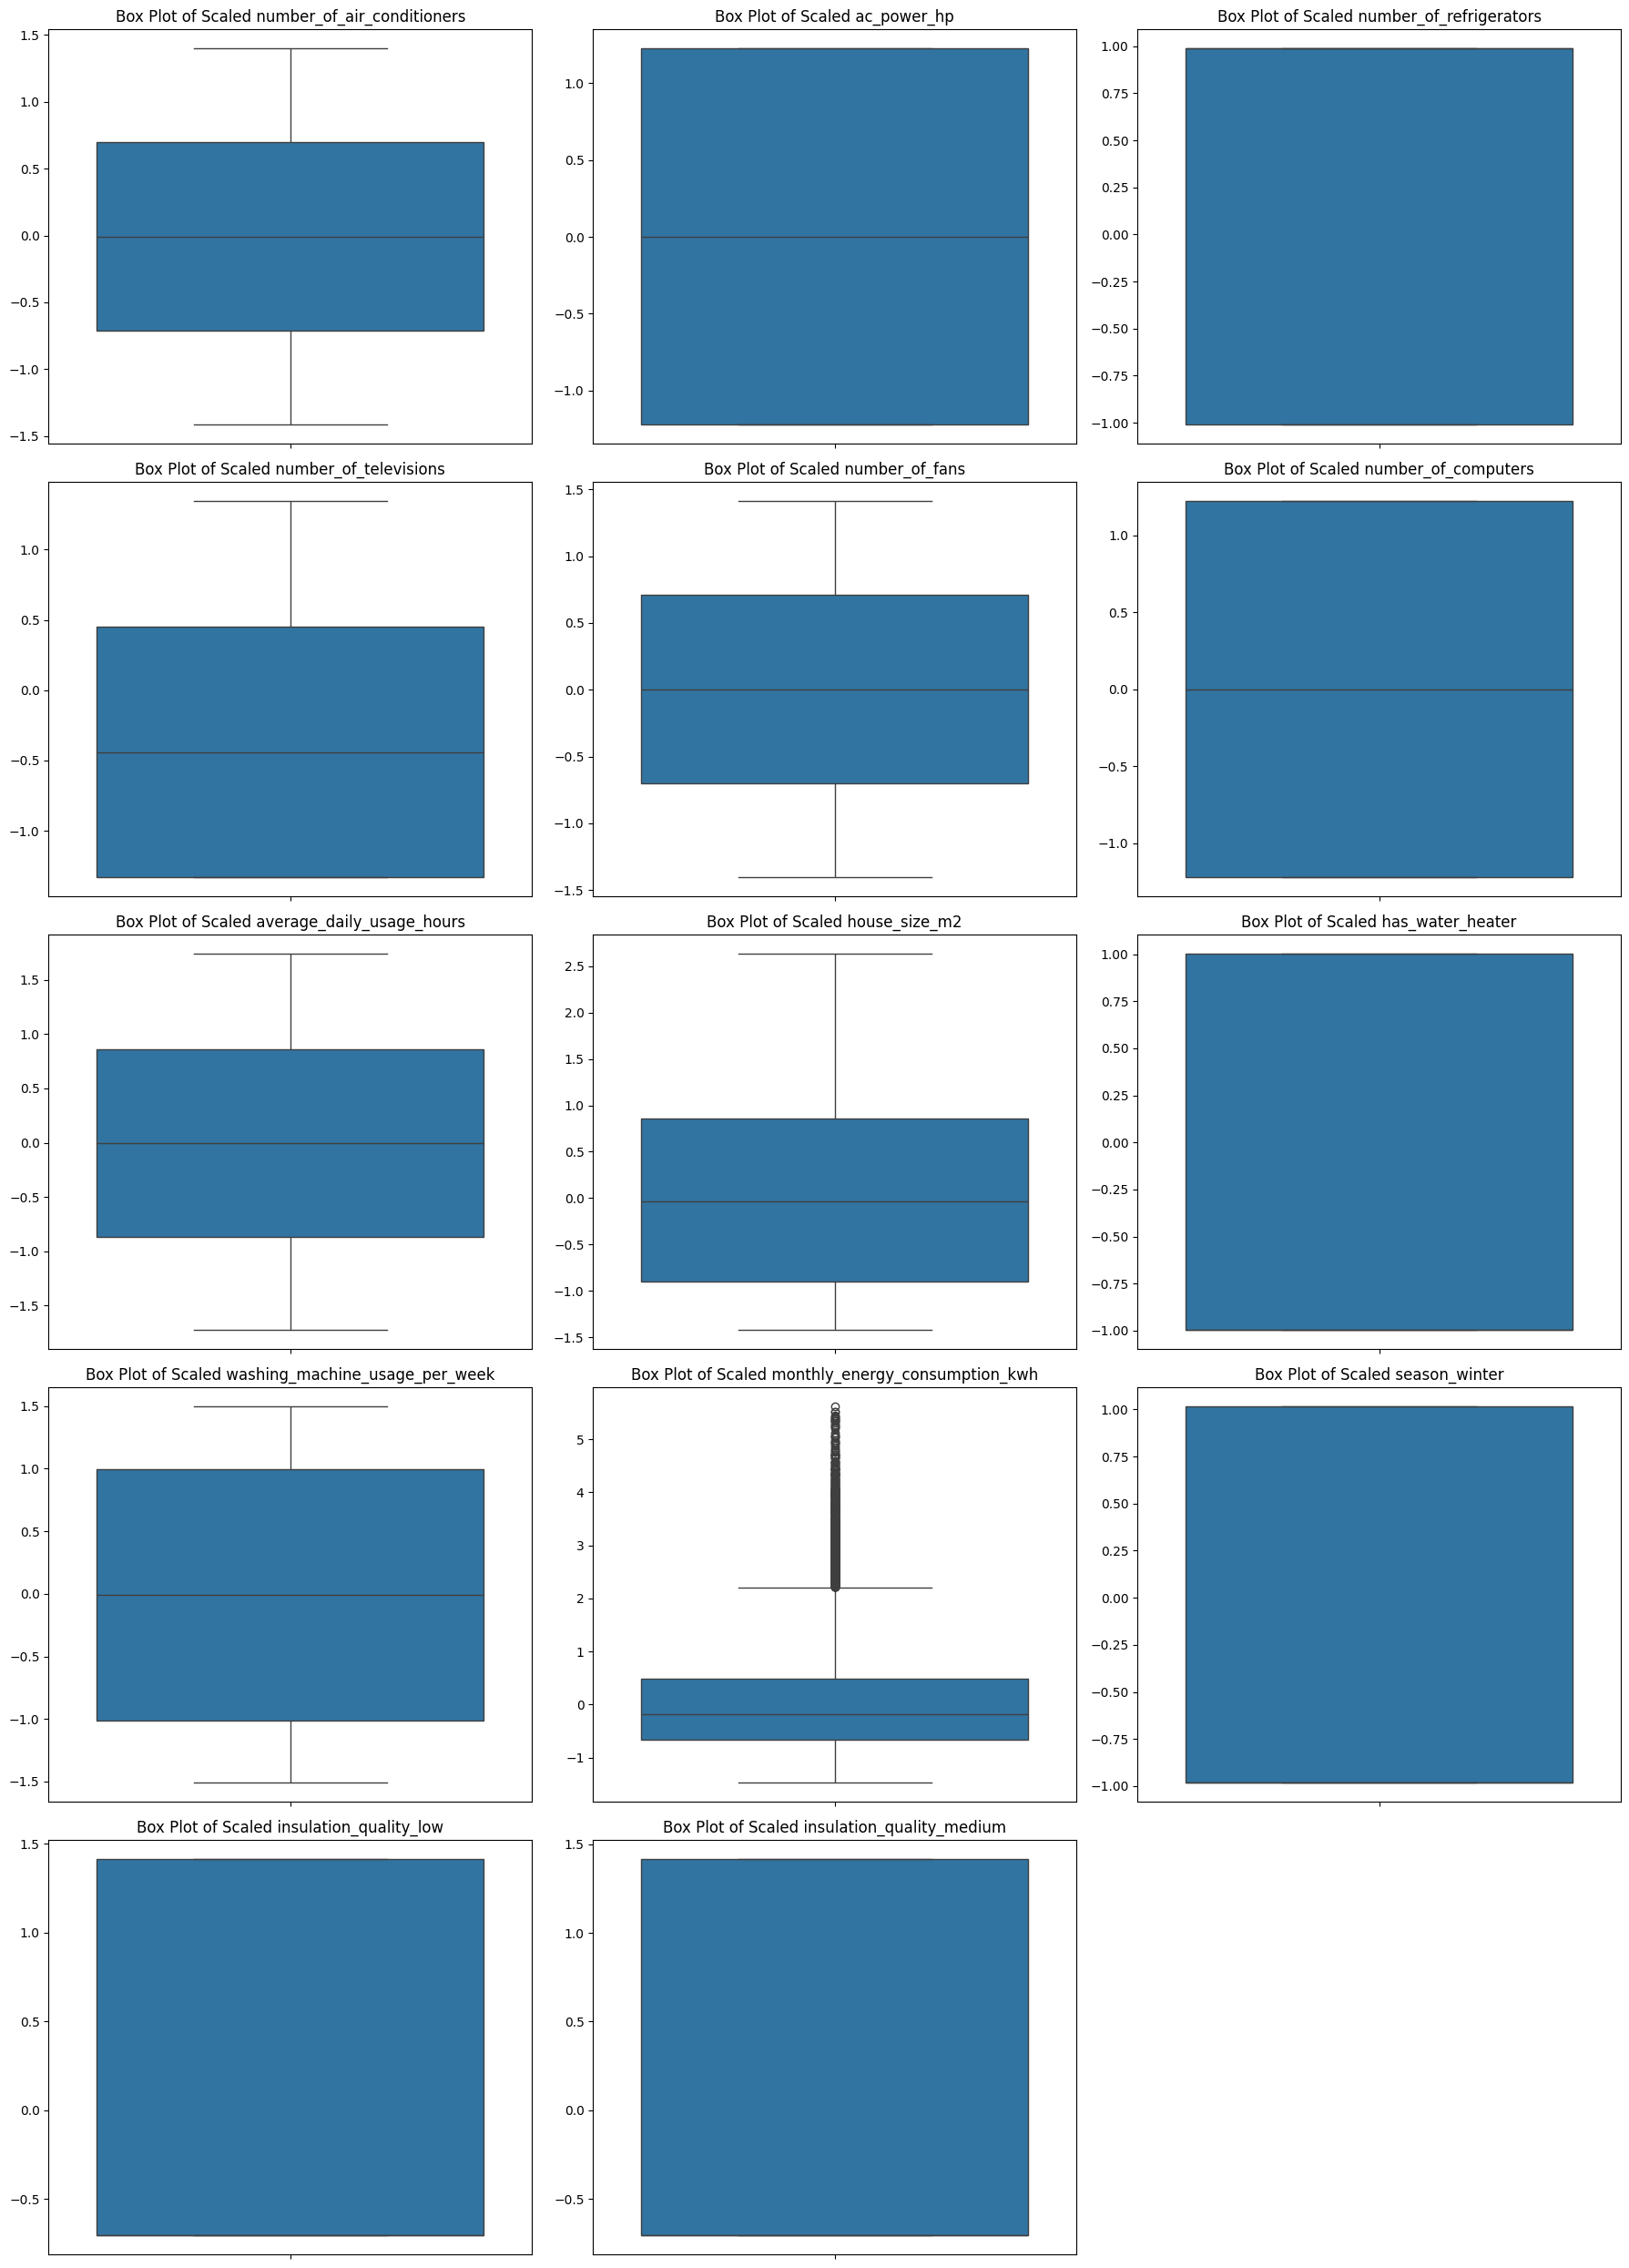


Outlier visualization complete. Further analysis or handling of outliers can be performed based on these plots.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection in scaled features
numerical_cols_scaled = X_scaled.select_dtypes(include=['number']).columns.tolist()

# Determine grid size for subplots dynamically
num_plots = len(numerical_cols_scaled)
rows = (num_plots + 2) // 3 # Roughly 3 columns per row

plt.figure(figsize=(18, 5 * rows))
for i, col in enumerate(numerical_cols_scaled):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(y=X_scaled[col])
    plt.title(f'Box Plot of Scaled {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

print('\nOutlier visualization complete. Further analysis or handling of outliers can be performed based on these plots.')

#### Handling Outliers (Noise Removal)

We will use the Interquartile Range (IQR) method to identify and remove outliers from the numerical features. This helps reduce noise and improve model performance by preventing extreme values from disproportionately influencing the training process. Please note that outlier removal should be done carefully, considering its potential impact on the data distribution and the specific goals of your analysis.

In [ ]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df_input, columns):
    df_out = df_input.copy()
    initial_shape = df_out.shape[0]
    for col in columns:
        # Exclude boolean columns from IQR outlier detection as it's not meaningful for them
        if pd.api.types.is_numeric_dtype(df_out[col]) and not pd.api.types.is_bool_dtype(df_out[col]):
            Q1 = df_out[col].quantile(0.25)
            Q3 = df_out[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    rows_removed = initial_shape - df_out.shape[0]
    print(f"Total rows removed due to outliers: {rows_removed} ({rows_removed/initial_shape:.2%})")
    return df_out

print(f"Original DataFrame shape before outlier removal: {df.shape}")

# Identify numerical feature columns to apply outlier removal. Exclude targets.
numerical_feature_cols = [col for col in df.columns if col not in ['monthly_energy_consumption_kwh', 'monthly_electricity_bill_egp'] and pd.api.types.is_numeric_dtype(df[col])]

df = remove_outliers_iqr(df, numerical_feature_cols)

print(f"DataFrame shape after outlier removal: {df.shape}")

Original DataFrame shape before outlier removal: (30000, 15)
Total rows removed due to outliers: 0 (0.00%)
DataFrame shape after outlier removal: (30000, 15)


In [ ]:
# Define features (X) and two targets (y1, y2)
# y1 for 'monthly_energy_consumption_kwh' and y2 for 'monthly_electricity_bill_egp'
X = df.drop(['monthly_electricity_bill_egp', 'monthly_energy_consumption_kwh'], axis=1)
y1 = df['monthly_energy_consumption_kwh']
y2 = df['monthly_electricity_bill_egp']
print("Features (X) and two targets (y1, y2) defined from the new dataset.")

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("All numerical features in X scaled using StandardScaler.")

print(f"Preprocessing complete for the new dataset. Final X_scaled shape: {X_scaled.shape}, y1 shape: {y1.shape}, y2 shape: {y2.shape}")

Features (X) and two targets (y1, y2) defined from the new dataset.
All numerical features in X scaled using StandardScaler.
Preprocessing complete for the new dataset. Final X_scaled shape: (30000, 13), y1 shape: (30000,), y2 shape: (30000,)


#### Splitting into Training and Testing Sets with Two Targets

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
# We need to ensure y1 and y2 are split consistently with X
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X_scaled, y1, y2, test_size=0.2, random_state=42
)

print(f'Original dataset shape after cleaning: {df.shape}')
print(f'Training features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')
print(f'Training target 1 (kwh) shape: {y1_train.shape}')
print(f'Testing target 1 (kwh) shape: {y1_test.shape}')
print(f'Training target 2 (bill) shape: {y2_train.shape}')
print(f'Testing target 2 (bill) shape: {y2_test.shape}')

print('\nData splitting complete. X_train, X_test, y1_train, y1_test, y2_train, y2_test are ready for model training.')

Original dataset shape after cleaning: (30000, 15)
Training features shape: (24000, 13)
Testing features shape: (6000, 13)
Training target 1 (kwh) shape: (24000,)
Testing target 1 (kwh) shape: (6000,)
Training target 2 (bill) shape: (24000,)
Testing target 2 (bill) shape: (6000,)

Data splitting complete. X_train, X_test, y1_train, y1_test, y2_train, y2_test are ready for model training.


### Machine Learning Models Training and Evaluation (for two targets)

We will train and evaluate multiple regression models for both `monthly_energy_consumption_kwh` (Target 1) and `monthly_electricity_bill_egp` (Target 2).

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Install CatBoost and LightGBM if not already installed
try:
    from catboost import CatBoostRegressor
except ImportError:
    !pip install catboost
    from catboost import CatBoostRegressor

try:
    from lightgbm import LGBMRegressor
except ImportError:
    !pip install lightgbm
    from lightgbm import LGBMRegressor


def train_evaluate_model(model, X_train, y_train, X_test, y_test, target_name):
    """Trains a model and evaluates its performance."""
    print(f"\n--- Training {model.__class__.__name__} for {target_name} ---")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on test set
    y_pred_test = model.predict(X_test)

    # Make predictions on train set
    y_pred_train = model.predict(X_train)

    # Evaluate metrics on test set
    mae_test = mean_absolute_error(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test) # Calculate RMSE from MSE
    r2_test = r2_score(y_test, y_pred_test)

    # Evaluate R² on train set
    r2_train = r2_score(y_train, y_pred_train)

    print(f'  Test MAE: {mae_test:.2f}')
    print(f'  Test MSE: {mse_test:.2f}')
    print(f'  Test RMSE: {rmse_test:.2f}')
    print(f'  Test R² Score: {r2_test:.2f}')
    print(f'  Train R² Score: {r2_train:.2f}')


    return {
        'model_name': model.__class__.__name__,
        'target': target_name,
        'mae_test': mae_test,
        'mse_test': mse_test,
        'rmse_test': rmse_test,
        'r2_test': r2_test,
        'r2_train': r2_train # Include train R2 in results
    }

# Store results for comparison
results = []

print("Setup complete. Ready to train and evaluate models.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
Setup complete. Ready to train and evaluate models.


#### 1. Linear Regression Model

In [ ]:
# Linear Regression for Target 1 (monthly_energy_consumption_kwh)
lr_model_y1 = LinearRegression()
results.append(train_evaluate_model(lr_model_y1, X_train, y1_train, X_test, y1_test, 'Monthly Energy Consumption (kWh)'))

# Linear Regression for Target 2 (monthly_electricity_bill_egp)
lr_model_y2 = LinearRegression()
results.append(train_evaluate_model(lr_model_y2, X_train, y2_train, X_test, y2_test, 'Monthly Electricity Bill (EGP)'))


--- Training LinearRegression for Monthly Energy Consumption (kWh) ---
  Test MAE: 330.33
  Test MSE: 219192.86
  Test RMSE: 468.18
  Test R² Score: 0.83
  Train R² Score: 0.83

--- Training LinearRegression for Monthly Electricity Bill (EGP) ---
  Test MAE: 396.42
  Test MSE: 315673.09
  Test RMSE: 561.85
  Test R² Score: 0.83
  Train R² Score: 0.83


#### 2. Decision Tree Regressor Model

In [ ]:
# Decision Tree for Target 1 (monthly_energy_consumption_kwh)
dt_model_y1 = DecisionTreeRegressor(random_state=42)
results.append(train_evaluate_model(dt_model_y1, X_train, y1_train, X_test, y1_test, 'Monthly Energy Consumption (kWh)'))

# Decision Tree for Target 2 (monthly_electricity_bill_egp)
dt_model_y2 = DecisionTreeRegressor(random_state=42)
results.append(train_evaluate_model(dt_model_y2, X_train, y2_train, X_test, y2_test, 'Monthly Electricity Bill (EGP)'))


--- Training DecisionTreeRegressor for Monthly Energy Consumption (kWh) ---
  Test MAE: 70.52
  Test MSE: 9185.87
  Test RMSE: 95.84
  Test R² Score: 0.99
  Train R² Score: 1.00

--- Training DecisionTreeRegressor for Monthly Electricity Bill (EGP) ---
  Test MAE: 86.32
  Test MSE: 13936.91
  Test RMSE: 118.05
  Test R² Score: 0.99
  Train R² Score: 1.00


#### 3. Random Forest Regressor Model

In [ ]:
# Random Forest for Target 1 (monthly_energy_consumption_kwh)
rf_model_y1 = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
results.append(train_evaluate_model(rf_model_y1, X_train, y1_train, X_test, y1_test, 'Monthly Energy Consumption (kWh)'))

# Random Forest for Target 2 (monthly_electricity_bill_egp)
rf_model_y2 = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
results.append(train_evaluate_model(rf_model_y2, X_train, y2_train, X_test, y2_test, 'Monthly Electricity Bill (EGP)'))


--- Training RandomForestRegressor for Monthly Energy Consumption (kWh) ---
  Test MAE: 54.89
  Test MSE: 5324.01
  Test RMSE: 72.97
  Test R² Score: 1.00
  Train R² Score: 1.00

--- Training RandomForestRegressor for Monthly Electricity Bill (EGP) ---
  Test MAE: 66.11
  Test MSE: 7712.38
  Test RMSE: 87.82
  Test R² Score: 1.00
  Train R² Score: 1.00


#### 4. K-Nearest Neighbors (KNN) Regressor Model

In [ ]:
# KNN for Target 1 (monthly_energy_consumption_kwh)
knn_model_y1 = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
results.append(train_evaluate_model(knn_model_y1, X_train, y1_train, X_test, y1_test, 'Monthly Energy Consumption (kWh)'))

# KNN for Target 2 (monthly_electricity_bill_egp)
knn_model_y2 = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
results.append(train_evaluate_model(knn_model_y2, X_train, y2_train, X_test, y2_test, 'Monthly Electricity Bill (EGP)'))


--- Training KNeighborsRegressor for Monthly Energy Consumption (kWh) ---
  Test MAE: 203.55
  Test MSE: 83443.16
  Test RMSE: 288.87
  Test R² Score: 0.94
  Train R² Score: 0.96

--- Training KNeighborsRegressor for Monthly Electricity Bill (EGP) ---
  Test MAE: 244.23
  Test MSE: 120119.61
  Test RMSE: 346.58
  Test R² Score: 0.94
  Train R² Score: 0.96


#### 5. CatBoost Regressor Model

In [ ]:
# CatBoost for Target 1 (monthly_energy_consumption_kwh)
cb_model_y1 = CatBoostRegressor(random_state=42, verbose=0)
results.append(train_evaluate_model(cb_model_y1, X_train, y1_train, X_test, y1_test, 'Monthly Energy Consumption (kWh)'))

# CatBoost for Target 2 (monthly_electricity_bill_egp)
cb_model_y2 = CatBoostRegressor(random_state=42, verbose=0)
results.append(train_evaluate_model(cb_model_y2, X_train, y2_train, X_test, y2_test, 'Monthly Electricity Bill (EGP)'))


--- Training CatBoostRegressor for Monthly Energy Consumption (kWh) ---
  Test MAE: 30.78
  Test MSE: 1778.37
  Test RMSE: 42.17
  Test R² Score: 1.00
  Train R² Score: 1.00

--- Training CatBoostRegressor for Monthly Electricity Bill (EGP) ---
  Test MAE: 37.31
  Test MSE: 2578.04
  Test RMSE: 50.77
  Test R² Score: 1.00
  Train R² Score: 1.00


#### 6. LightGBM Regressor Model

In [ ]:
# LightGBM for Target 1 (monthly_energy_consumption_kwh)
lgbm_model_y1 = LGBMRegressor(random_state=42, n_jobs=-1)
results.append(train_evaluate_model(lgbm_model_y1, X_train, y1_train, X_test, y1_test, 'Monthly Energy Consumption (kWh)'))

# LightGBM for Target 2 (monthly_electricity_bill_egp)
lgbm_model_y2 = LGBMRegressor(random_state=42, n_jobs=-1)
results.append(train_evaluate_model(lgbm_model_y2, X_train, y2_train, X_test, y2_test, 'Monthly Electricity Bill (EGP)'))


--- Training LGBMRegressor for Monthly Energy Consumption (kWh) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 13
[LightGBM] [Info] Start training from score 2542.700815
  Test MAE: 45.22
  Test MSE: 3500.53
  Test RMSE: 59.17
  Test R² Score: 1.00
  Train R² Score: 1.00

--- Training LGBMRegressor for Monthly Electricity Bill (EGP) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 13
[LightGBM] [Info] Start training from score 3051.153741
  Test MAE: 55.67
  Test MSE: 5404.83
  Test RMSE: 73.52
  Test R² Score: 

#### 7. XGBoost Regressor Model

In [ ]:
from xgboost import XGBRegressor

# XGBoost for Target 1 (monthly_energy_consumption_kwh)
xgb_model_y1 = XGBRegressor(random_state=42, n_jobs=-1)
results.append(train_evaluate_model(xgb_model_y1, X_train, y1_train, X_test, y1_test, 'Monthly Energy Consumption (kWh)'))

# XGBoost for Target 2 (monthly_electricity_bill_egp)
xgb_model_y2 = XGBRegressor(random_state=42, n_jobs=-1)
results.append(train_evaluate_model(xgb_model_y2, X_train, y2_train, X_test, y2_test, 'Monthly Electricity Bill (EGP)'))


--- Training XGBRegressor for Monthly Energy Consumption (kWh) ---
  Test MAE: 52.96
  Test MSE: 4842.51
  Test RMSE: 69.59
  Test R² Score: 1.00
  Train R² Score: 1.00

--- Training XGBRegressor for Monthly Electricity Bill (EGP) ---
  Test MAE: 64.70
  Test MSE: 7354.12
  Test RMSE: 85.76
  Test R² Score: 1.00
  Train R² Score: 1.00


### Deep Learning Model: Multi-Output Neural Network

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the input layer
input_layer = layers.Input(shape=(X_train.shape[1],), name='input_layer')

# Shared hidden layers
x = layers.Dense(128, activation='relu', name='shared_hidden_1')(input_layer)
x = layers.Dense(64, activation='relu', name='shared_hidden_2')(x)

# Output branch for monthly_energy_consumption_kwh (Target 1)
output_kwh = layers.Dense(32, activation='relu', name='kwh_hidden_1')(x)
output_kwh = layers.Dense(1, name='monthly_energy_consumption_kwh_output')(output_kwh)

# Output branch for monthly_electricity_bill_egp (Target 2)
output_bill = layers.Dense(32, activation='relu', name='bill_hidden_1')(x)
output_bill = layers.Dense(1, name='monthly_electricity_bill_egp_output')(output_bill)

# Create the multi-output model
multi_output_model = Model(inputs=input_layer, outputs=[output_kwh, output_bill])

# Compile the model with separate losses for each output
multi_output_model.compile(optimizer='adam', loss={'monthly_energy_consumption_kwh_output': 'mse', 'monthly_electricity_bill_egp_output': 'mse'})

multi_output_model.summary()
print('\nMulti-Output Neural Network model built and compiled successfully!')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_hidden_1     │ (None, 128)       │      1,792 │ input_layer[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_hidden_2     │ (None, 64)        │      8,256 │ shared_hidden_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kwh_hidden_1        │ (None, 32)        │      2,080 │ shared_hidden_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bill_hidden_1       │ (None, 32)        │      2,080 │ shared_hidden_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_energy_con… │ (None, 1)         │         33 │ kwh_hidden_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_electricit… │ (None, 1)         │         33 │ bill_hidden_1[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,274 (55.76 KB)

 Trainable params: 14,274 (55.76 KB)

 Non-trainable params: 0 (0.00 B)


Multi-Output Neural Network model built and compiled successfully!


#### Train the Multi-Output Neural Network Model

In [ ]:
# Train the model with both target variables
history_multi_output = multi_output_model.fit(
    X_train,
    {'monthly_energy_consumption_kwh_output': y1_train, 'monthly_electricity_bill_egp_output': y2_train},
    epochs=100, # Number of training iterations
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data for validation during training
    verbose=0 # Suppress verbose output during training
)

print('\nMulti-Output Neural Network model trained successfully!')


Multi-Output Neural Network model trained successfully!


#### Evaluate the Multi-Output Neural Network Model on Test Data

In [ ]:
# Evaluate the model on the test data
loss_multi_output = multi_output_model.evaluate(
    X_test,
    {'monthly_energy_consumption_kwh_output': y1_test, 'monthly_electricity_bill_egp_output': y2_test},
    verbose=0
)

print(f'Multi-Output NN Test Loss (Total MSE): {loss_multi_output[0]:.2f}')
print(f'Multi-Output NN Test Loss (kWh MSE): {loss_multi_output[1]:.2f}')
print(f'Multi-Output NN Test Loss (Bill EGP MSE): {loss_multi_output[2]:.2f}')

# Make predictions for R² and other metrics
y1_pred_nn_multi_test, y2_pred_nn_multi_test = multi_output_model.predict(X_test)
y1_pred_nn_multi_train, y2_pred_nn_multi_train = multi_output_model.predict(X_train)

# Evaluate Target 1 (kWh) - Test Set
mae_y1_nn_multi_test = mean_absolute_error(y1_test, y1_pred_nn_multi_test)
mse_y1_nn_multi_test = mean_squared_error(y1_test, y1_pred_nn_multi_test)
rmse_y1_nn_multi_test = np.sqrt(mse_y1_nn_multi_test)
r2_y1_nn_multi_test = r2_score(y1_test, y1_pred_nn_multi_test)

# Evaluate Target 1 (kWh) - Train Set
r2_y1_nn_multi_train = r2_score(y1_train, y1_pred_nn_multi_train)

print(f'\nMulti-Output NN (kWh) Test MAE: {mae_y1_nn_multi_test:.2f}')
print(f'Multi-Output NN (kWh) Test MSE: {mse_y1_nn_multi_test:.2f}')
print(f'Multi-Output NN (kWh) Test RMSE: {rmse_y1_nn_multi_test:.2f}')
print(f'Multi-Output NN (kWh) Test R² Score: {r2_y1_nn_multi_test:.2f}')
print(f'Multi-Output NN (kWh) Train R² Score: {r2_y1_nn_multi_train:.2f}')

# Evaluate Target 2 (Bill EGP) - Test Set
mae_y2_nn_multi_test = mean_absolute_error(y2_test, y2_pred_nn_multi_test)
mse_y2_nn_multi_test = mean_squared_error(y2_test, y2_pred_nn_multi_test)
rmse_y2_nn_multi_test = np.sqrt(mse_y2_nn_multi_test)
r2_y2_nn_multi_test = r2_score(y2_test, y2_pred_nn_multi_test)

# Evaluate Target 2 (Bill EGP) - Train Set
r2_y2_nn_multi_train = r2_score(y2_train, y2_pred_nn_multi_train)

print(f'\nMulti-Output NN (Bill EGP) Test MAE: {mae_y2_nn_multi_test:.2f}')
print(f'Multi-Output NN (Bill EGP) Test MSE: {mse_y2_nn_multi_test:.2f}')
print(f'Multi-Output NN (Bill EGP) Test RMSE: {rmse_y2_nn_multi_test:.2f}')
print(f'Multi-Output NN (Bill EGP) Test R² Score: {r2_y2_nn_multi_test:.2f}')
print(f'Multi-Output NN (Bill EGP) Train R² Score: {r2_y2_nn_multi_train:.2f}')

results.append({
    'model_name': 'MultiOutput_NN_kWh',
    'target': 'Monthly Energy Consumption (kWh)',
    'mae_test': mae_y1_nn_multi_test,
    'mse_test': mse_y1_nn_multi_test,
    'rmse_test': rmse_y1_nn_multi_test,
    'r2_test': r2_y1_nn_multi_test,
    'r2_train': r2_y1_nn_multi_train
})
results.append({
    'model_name': 'MultiOutput_NN_Bill',
    'target': 'Monthly Electricity Bill (EGP)',
    'mae_test': mae_y2_nn_multi_test,
    'mse_test': mse_y2_nn_multi_test,
    'rmse_test': rmse_y2_nn_multi_test,
    'r2_test': r2_y2_nn_multi_test,
    'r2_train': r2_y2_nn_multi_train
})

Multi-Output NN Test Loss (Total MSE): 5882.78
Multi-Output NN Test Loss (kWh MSE): 2424.52
Multi-Output NN Test Loss (Bill EGP MSE): 3459.50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step

Multi-Output NN (kWh) Test MAE: 37.71
Multi-Output NN (kWh) Test MSE: 2423.55
Multi-Output NN (kWh) Test RMSE: 49.23
Multi-Output NN (kWh) Test R² Score: 1.00
Multi-Output NN (kWh) Train R² Score: 1.00

Multi-Output NN (Bill EGP) Test MAE: 45.11
Multi-Output NN (Bill EGP) Test MSE: 3459.23
Multi-Output NN (Bill EGP) Test RMSE: 58.82
Multi-Output NN (Bill EGP) Test R² Score: 1.00
Multi-Output NN (Bill EGP) Train R² Score: 1.00


### Download Trained Models

In [ ]:
import joblib
import os
import tensorflow as tf # Added for Keras model saving

# Define a directory to save models
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

print(f"Saving models to directory: {model_dir}/")

# 1. Save CatBoostRegressor models
if 'cb_model_y1' in locals() and 'cb_model_y2' in locals():
    joblib.dump(cb_model_y1, os.path.join(model_dir, 'catboost_kwh_model.joblib'))
    joblib.dump(cb_model_y2, os.path.join(model_dir, 'catboost_bill_model.joblib'))
    print("CatBoostRegressor models saved successfully.")
else:
    print("Skipping CatBoostRegressor models save: 'cb_model_y1' or 'cb_model_y2' not found. Please ensure the training cells for these models have been run.")

# 2. Save Multi-Output Neural Network model
if 'multi_output_model' in locals():
    multi_output_model.save(os.path.join(model_dir, 'multi_output_nn_model.h5'))
    print("Multi-Output Neural Network model saved successfully.")
else:
    print("Skipping Multi-Output Neural Network model save: 'multi_output_model' not found. Please ensure the training cell for this model has been run.")

print("All selected models are processed for saving.")

Saving models to directory: trained_models/
CatBoostRegressor models saved successfully.
Multi-Output Neural Network model saved successfully.
All selected models are processed for saving.


### Deep Learning Model: Multi-Output LSTM Neural Network

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reshape input data for LSTM: (samples, timesteps, features)
# We'll treat each feature as a single timestep for simplicity since it's not strictly time-series data.
X_train_lstm = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

# Define the input layer
input_layer_lstm = layers.Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), name='lstm_input_layer')

# Shared LSTM layer
x_lstm = layers.LSTM(128, activation='relu', name='shared_lstm_1')(input_layer_lstm)
x_lstm = layers.Dense(64, activation='relu', name='shared_dense_1')(x_lstm)

# Output branch for monthly_energy_consumption_kwh (Target 1)
output_kwh_lstm = layers.Dense(32, activation='relu', name='lstm_kwh_hidden_1')(x_lstm)
output_kwh_lstm = layers.Dense(1, name='lstm_monthly_energy_consumption_kwh_output')(output_kwh_lstm)

# Output branch for monthly_electricity_bill_egp (Target 2)
output_bill_lstm = layers.Dense(32, activation='relu', name='lstm_bill_hidden_1')(x_lstm)
output_bill_lstm = layers.Dense(1, name='lstm_monthly_electricity_bill_egp_output')(output_bill_lstm)

# Create the multi-output LSTM model
multi_output_lstm_model = Model(inputs=input_layer_lstm, outputs=[output_kwh_lstm, output_bill_lstm])

# Compile the model with separate losses for each output
multi_output_lstm_model.compile(optimizer='adam', loss={'lstm_monthly_energy_consumption_kwh_output': 'mse', 'lstm_monthly_electricity_bill_egp_output': 'mse'})

multi_output_lstm_model.summary()
print('\nMulti-Output LSTM Neural Network model built and compiled successfully!')

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_input_layer    │ (None, 1, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_1       │ (None, 128)       │     72,704 │ lstm_input_layer… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 64)        │      8,256 │ shared_lstm_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_kwh_hidden_1   │ (None, 32)        │      2,080 │ shared_dense_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_bill_hidden_1  │ (None, 32)        │      2,080 │ shared_dense_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_monthly_energ… │ (None, 1)         │         33 │ lstm_kwh_hidden_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_monthly_elect… │ (None, 1)         │         33 │ lstm_bill_hidden… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 85,186 (332.76 KB)

 Trainable params: 85,186 (332.76 KB)

 Non-trainable params: 0 (0.00 B)


Multi-Output LSTM Neural Network model built and compiled successfully!


#### Train the Multi-Output LSTM Neural Network Model

In [ ]:
# Train the LSTM model with both target variables
history_multi_output_lstm = multi_output_lstm_model.fit(
    X_train_lstm,
    {'lstm_monthly_energy_consumption_kwh_output': y1_train, 'lstm_monthly_electricity_bill_egp_output': y2_train},
    epochs=100, # Number of training iterations
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data for validation during training
    verbose=0 # Suppress verbose output during training
)

print('\nMulti-Output LSTM Neural Network model trained successfully!')


Multi-Output LSTM Neural Network model trained successfully!


#### Evaluate the Multi-Output LSTM Neural Network Model on Test Data

In [ ]:
# Evaluate the model on the test data
loss_multi_output_lstm = multi_output_lstm_model.evaluate(
    X_test_lstm,
    {'lstm_monthly_energy_consumption_kwh_output': y1_test, 'lstm_monthly_electricity_bill_egp_output': y2_test},
    verbose=0
)

print(f'Multi-Output LSTM NN Test Loss (Total MSE): {loss_multi_output_lstm[0]:.2f}')
print(f'Multi-Output LSTM NN Test Loss (kWh MSE): {loss_multi_output_lstm[1]:.2f}')
print(f'Multi-Output LSTM NN Test Loss (Bill EGP MSE): {loss_multi_output_lstm[2]:.2f}')

# Make predictions for R² and other metrics
y1_pred_nn_multi_lstm_test, y2_pred_nn_multi_lstm_test = multi_output_lstm_model.predict(X_test_lstm)
y1_pred_nn_multi_lstm_train, y2_pred_nn_multi_lstm_train = multi_output_lstm_model.predict(X_train_lstm)

# Evaluate Target 1 (kWh) - Test Set
mae_y1_nn_multi_lstm_test = mean_absolute_error(y1_test, y1_pred_nn_multi_lstm_test)
mse_y1_nn_multi_lstm_test = mean_squared_error(y1_test, y1_pred_nn_multi_lstm_test)
rmse_y1_nn_multi_lstm_test = np.sqrt(mse_y1_nn_multi_lstm_test)
r2_y1_nn_multi_lstm_test = r2_score(y1_test, y1_pred_nn_multi_lstm_test)

# Evaluate Target 1 (kWh) - Train Set
r2_y1_nn_multi_lstm_train = r2_score(y1_train, y1_pred_nn_multi_lstm_train)

print(f'\nMulti-Output LSTM NN (kWh) Test MAE: {mae_y1_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (kWh) Test MSE: {mse_y1_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (kWh) Test RMSE: {rmse_y1_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (kWh) Test R² Score: {r2_y1_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (kWh) Train R² Score: {r2_y1_nn_multi_lstm_train:.2f}')

# Evaluate Target 2 (Bill EGP) - Test Set
mae_y2_nn_multi_lstm_test = mean_absolute_error(y2_test, y2_pred_nn_multi_lstm_test)
mse_y2_nn_multi_lstm_test = mean_squared_error(y2_test, y2_pred_nn_multi_lstm_test)
rmse_y2_nn_multi_lstm_test = np.sqrt(mse_y2_nn_multi_lstm_test)
r2_y2_nn_multi_lstm_test = r2_score(y2_test, y2_pred_nn_multi_lstm_test)

# Evaluate Target 2 (Bill EGP) - Train Set
r2_y2_nn_multi_lstm_train = r2_score(y2_train, y2_pred_nn_multi_lstm_train)

print(f'\nMulti-Output LSTM NN (Bill EGP) Test MAE: {mae_y2_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (Bill EGP) Test MSE: {mse_y2_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (Bill EGP) Test RMSE: {rmse_y2_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (Bill EGP) Test R² Score: {r2_y2_nn_multi_lstm_test:.2f}')
print(f'Multi-Output LSTM NN (Bill EGP) Train R² Score: {r2_y2_nn_multi_lstm_train:.2f}')

results.append({
    'model_name': 'MultiOutput_LSTM_kWh',
    'target': 'Monthly Energy Consumption (kWh)',
    'mae_test': mae_y1_nn_multi_lstm_test,
    'mse_test': mse_y1_nn_multi_lstm_test,
    'rmse_test': rmse_y1_nn_multi_lstm_test,
    'r2_test': r2_y1_nn_multi_lstm_test,
    'r2_train': r2_y1_nn_multi_lstm_train
})
results.append({
    'model_name': 'MultiOutput_LSTM_Bill',
    'target': 'Monthly Electricity Bill (EGP)',
    'mae_test': mae_y2_nn_multi_lstm_test,
    'mse_test': mse_y2_nn_multi_lstm_test,
    'rmse_test': rmse_y2_nn_multi_lstm_test,
    'r2_test': r2_y2_nn_multi_lstm_test,
    'r2_train': r2_y2_nn_multi_lstm_train
})

Multi-Output LSTM NN Test Loss (Total MSE): 4594.48
Multi-Output LSTM NN Test Loss (kWh MSE): 1874.08
Multi-Output LSTM NN Test Loss (Bill EGP MSE): 2717.58
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Multi-Output LSTM NN (kWh) Test MAE: 32.07
Multi-Output LSTM NN (kWh) Test MSE: 1875.04
Multi-Output LSTM NN (kWh) Test RMSE: 43.30
Multi-Output LSTM NN (kWh) Test R² Score: 1.00
Multi-Output LSTM NN (kWh) Train R² Score: 1.00

Multi-Output LSTM NN (Bill EGP) Test MAE: 38.69
Multi-Output LSTM NN (Bill EGP) Test MSE: 2719.43
Multi-Output LSTM NN (Bill EGP) Test RMSE: 52.15
Multi-Output LSTM NN (Bill EGP) Test R² Score: 1.00
Multi-Output LSTM NN (Bill EGP) Train R² Score: 1.00


### Model Comparison

In [ ]:
import pandas as pd

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)

# Select and rename columns to match the desired output format
performance_df = results_df[['model_name', 'target', 'r2_test', 'rmse_test', 'mae_test']].copy()
performance_df.rename(columns={
    'r2_test': 'R²',
    'rmse_test': 'RMSE',
    'mae_test': 'MAE'
}, inplace=True)

print("\n--- Model Performance Comparison (Test Set) ---")
# Sort by R² Score (test) for better comparison, in descending order for accuracy
performance_df_sorted = performance_df.sort_values(by=['R²'], ascending=False)
display(performance_df_sorted)

print("\n--- Best Model for each Metric ---")

# Separate results for kWh and Bill targets to find the best for each
kwh_performance = performance_df[performance_df['target'] == 'Monthly Energy Consumption (kWh)']
bill_performance = performance_df[performance_df['target'] == 'Monthly Electricity Bill (EGP)']

if not kwh_performance.empty:
    best_r2_kwh_model = kwh_performance.loc[kwh_performance['R²'].idxmax()]
    best_rmse_kwh_model = kwh_performance.loc[kwh_performance['RMSE'].idxmin()]
    best_mae_kwh_model = kwh_performance.loc[kwh_performance['MAE'].idxmin()]

    print("\nBest for Monthly Energy Consumption (kWh):")
    print(f"  Best R²: {best_r2_kwh_model['model_name']} with R² = {best_r2_kwh_model['R²']:.4f}")
    print(f"  Best RMSE: {best_rmse_kwh_model['model_name']} with RMSE = {best_rmse_kwh_model['RMSE']:.2f}")
    print(f"  Best MAE: {best_mae_kwh_model['model_name']} with MAE = {best_mae_kwh_model['MAE']:.2f}")

if not bill_performance.empty:
    best_r2_bill_model = bill_performance.loc[bill_performance['R²'].idxmax()]
    best_rmse_bill_model = bill_performance.loc[bill_performance['RMSE'].idxmin()]
    best_mae_bill_model = bill_performance.loc[bill_performance['MAE'].idxmin()]

    print("\nBest for Monthly Electricity Bill (EGP):")
    print(f"  Best R²: {best_r2_bill_model['model_name']} with R² = {best_r2_bill_model['R²']:.4f}")
    print(f"  Best RMSE: {best_rmse_bill_model['model_name']} with RMSE = {best_rmse_bill_model['RMSE']:.2f}")
    print(f"  Best MAE: {best_mae_bill_model['model_name']} with MAE = {best_mae_bill_model['MAE']:.2f}")


print("\n--- Overall Best Model (considering R² as primary metric across all targets) ---")
# Find the overall best model by R²
overall_best_model_row = performance_df.loc[performance_df['R²'].idxmax()]
print(f"The overall best model is: {overall_best_model_row['model_name']} for {overall_best_model_row['target']}")
print(f"With R²: {overall_best_model_row['R²']:.4f}, RMSE: {overall_best_model_row['RMSE']:.2f}, MAE: {overall_best_model_row['MAE']:.2f}")


--- Model Performance Comparison (Test Set) ---


,model_name,target,R²,RMSE,MAE
8,CatBoostRegressor,Monthly Energy Consumption (kWh),0.998641,42.170734,30.777474
9,CatBoostRegressor,Monthly Electricity Bill (EGP),0.998632,50.774434,37.306995
18,MultiOutput_LSTM_kWh,Monthly Energy Consumption (kWh),0.998567,43.301781,32.074304
19,MultiOutput_LSTM_Bill,Monthly Electricity Bill (EGP),0.998557,52.148162,38.692325
14,MultiOutput_LSTM_kWh,Monthly Energy Consumption (kWh),0.998551,43.543706,32.302815
15,MultiOutput_LSTM_Bill,Monthly Electricity Bill (EGP),0.998535,52.544108,39.122889
13,MultiOutput_NN_Bill,Monthly Electricity Bill (EGP),0.998164,58.815234,45.110245
12,MultiOutput_NN_kWh,Monthly Energy Consumption (kWh),0.998148,49.229538,37.708806
10,LGBMRegressor,Monthly Energy Consumption (kWh),0.997325,59.165289,45.216548
11,LGBMRegressor,Monthly Electricity Bill (EGP),0.997132,73.517516,55.669702



--- Best Model for each Metric ---

Best for Monthly Energy Consumption (kWh):
  Best R²: CatBoostRegressor with R² = 0.9986
  Best RMSE: CatBoostRegressor with RMSE = 42.17
  Best MAE: CatBoostRegressor with MAE = 30.78

Best for Monthly Electricity Bill (EGP):
  Best R²: CatBoostRegressor with R² = 0.9986
  Best RMSE: CatBoostRegressor with RMSE = 50.77
  Best MAE: CatBoostRegressor with MAE = 37.31

--- Overall Best Model (considering R² as primary metric across all targets) ---
The overall best model is: CatBoostRegressor for Monthly Energy Consumption (kWh)
With R²: 0.9986, RMSE: 42.17, MAE: 30.78


### Feature Importance Analysis

Plotting feature importances...


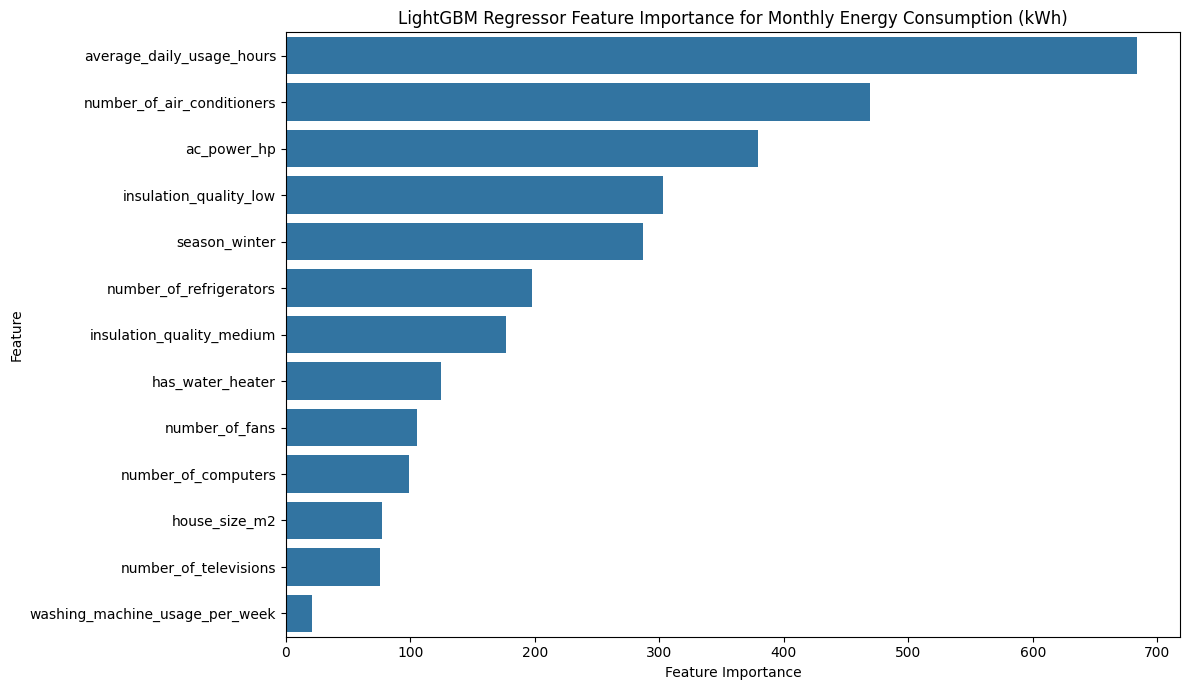

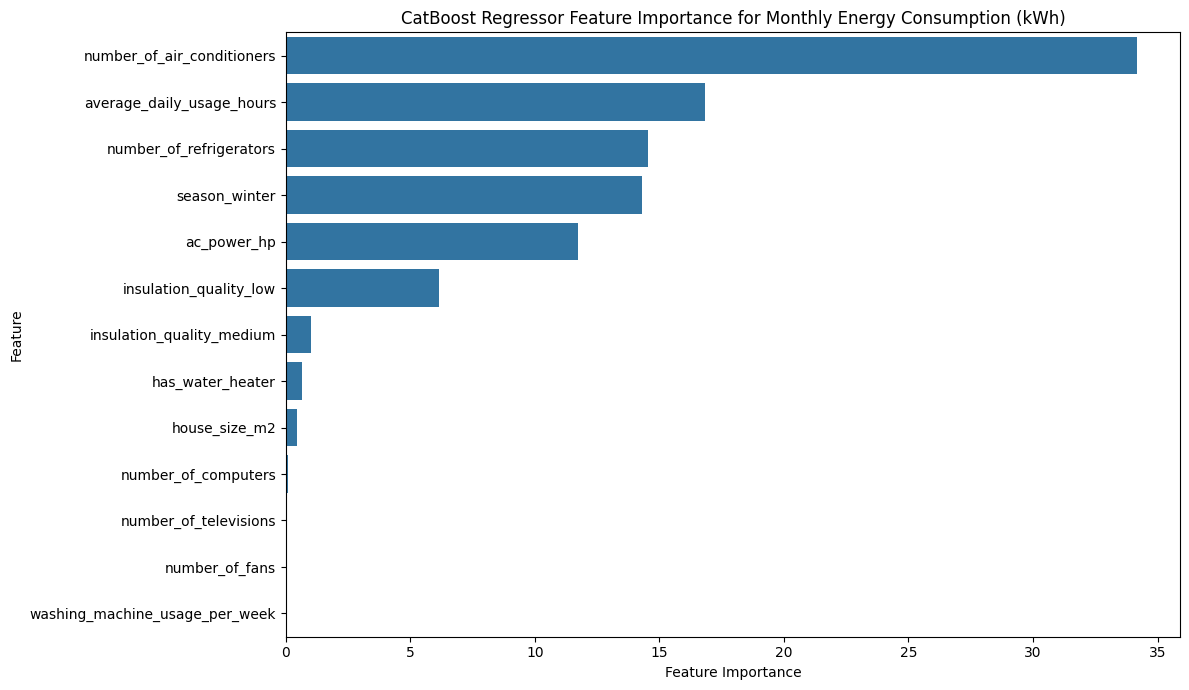

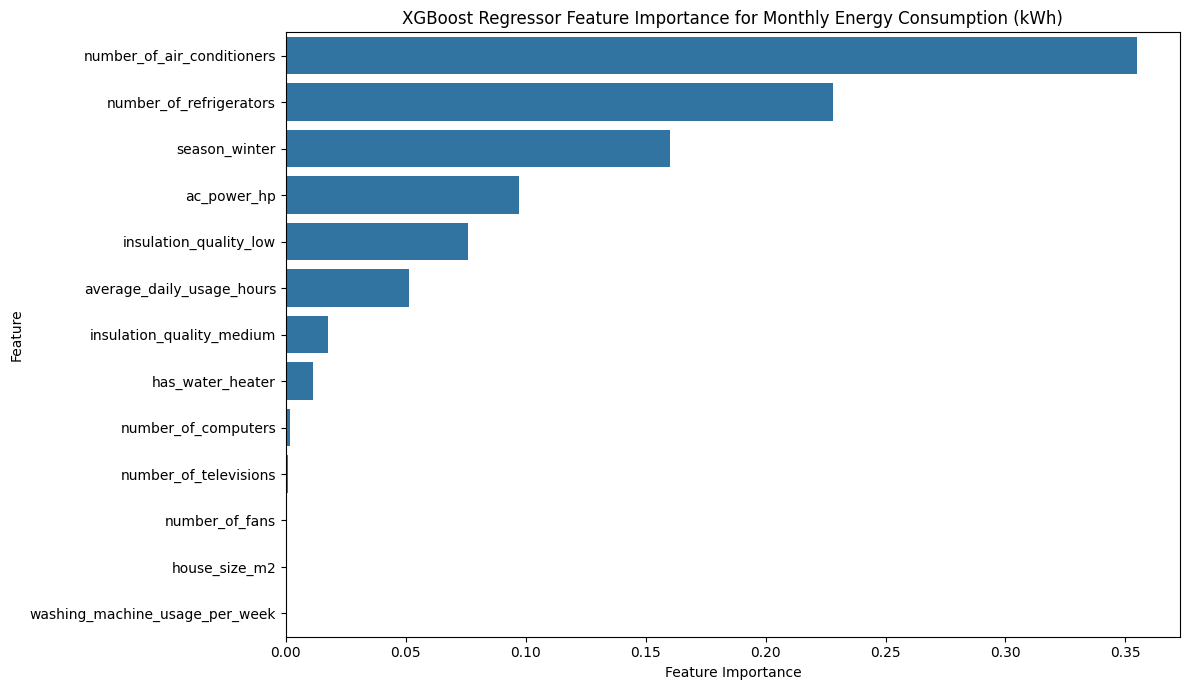

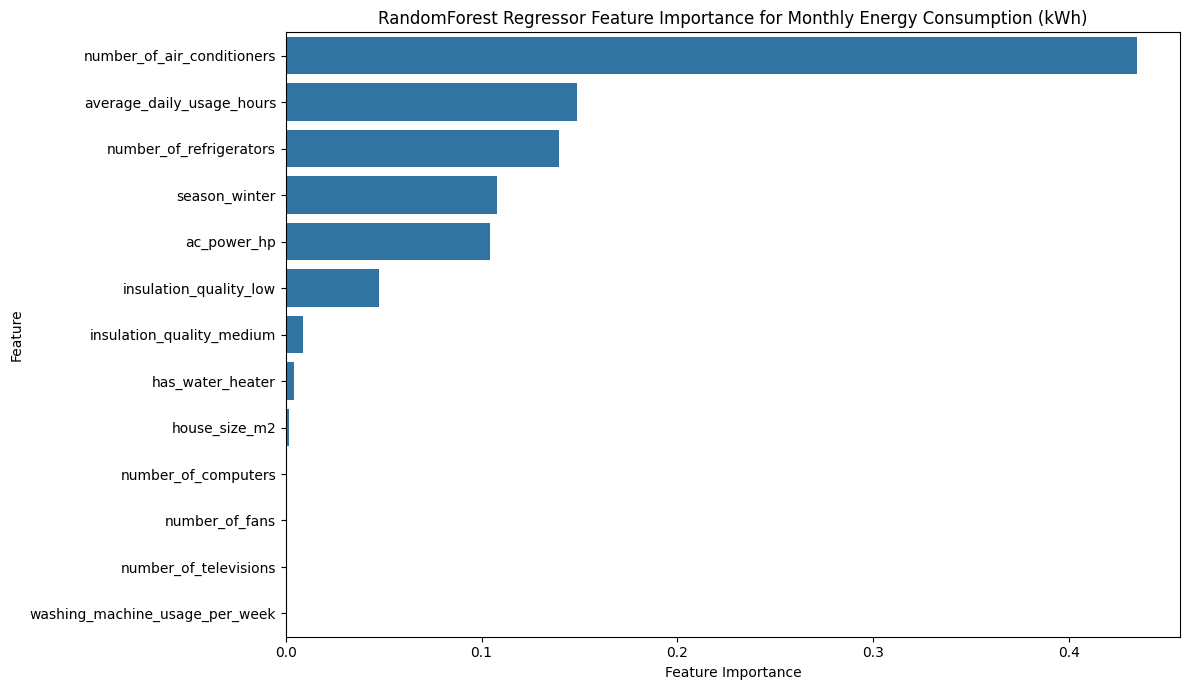

Feature importance plots generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names, model_name, target_name='Monthly Energy Consumption (kWh)'):
    """Plots feature importance for a given model."""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'): # For linear models like LinearRegression
        importances = abs(model.coef_)
    elif hasattr(model, 'get_feature_importance'): # For CatBoost
        importances = model.get_feature_importance()
    else:
        print(f"Feature importance not directly available for {model_name}")
        return

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(f'{model_name} Feature Importance for {target_name}')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

# Get feature names from X_train
feature_names = X_train.columns

print('Plotting feature importances...')

# 1. LightGBM Feature Importance (kWh)
plot_feature_importance(lgbm_model_y1, feature_names, 'LightGBM Regressor')

# 2. CatBoost Feature Importance (kWh)
plot_feature_importance(cb_model_y1, feature_names, 'CatBoost Regressor')

# 3. XGBoost Feature Importance (kWh)
plot_feature_importance(xgb_model_y1, feature_names, 'XGBoost Regressor')

# 4. RandomForest Feature Importance (kWh)
plot_feature_importance(rf_model_y1, feature_names, 'RandomForest Regressor')

print('Feature importance plots generated.')

### Feature Importance Analysis for Monthly Electricity Bill (EGP)

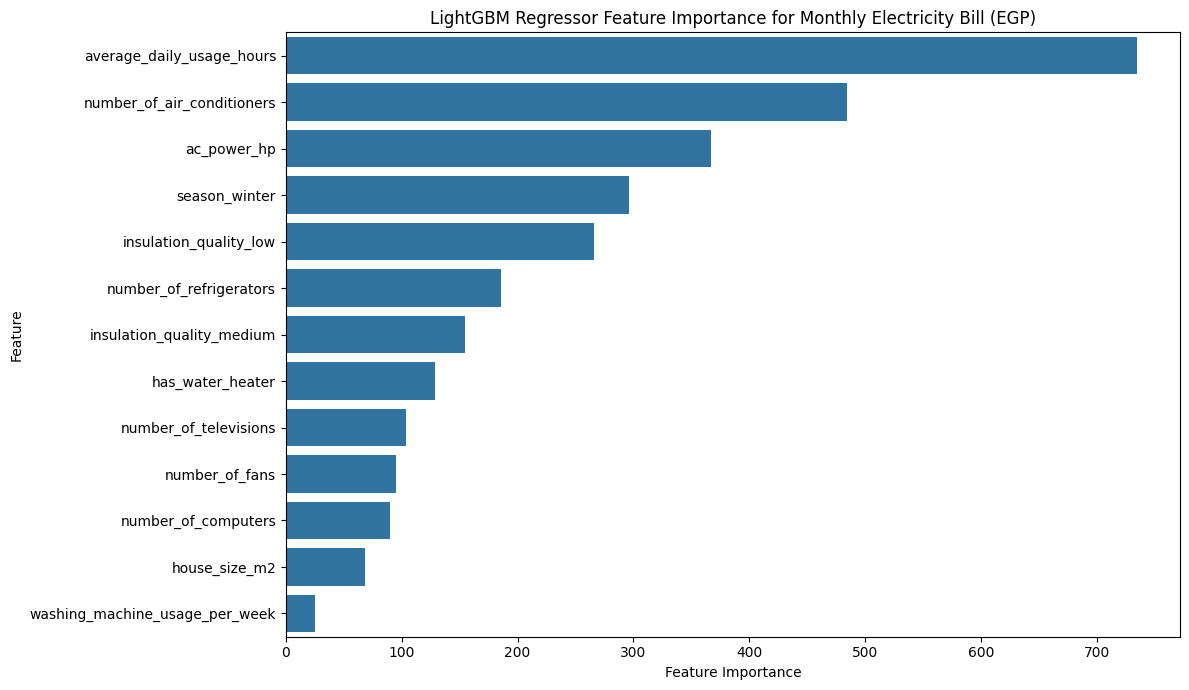

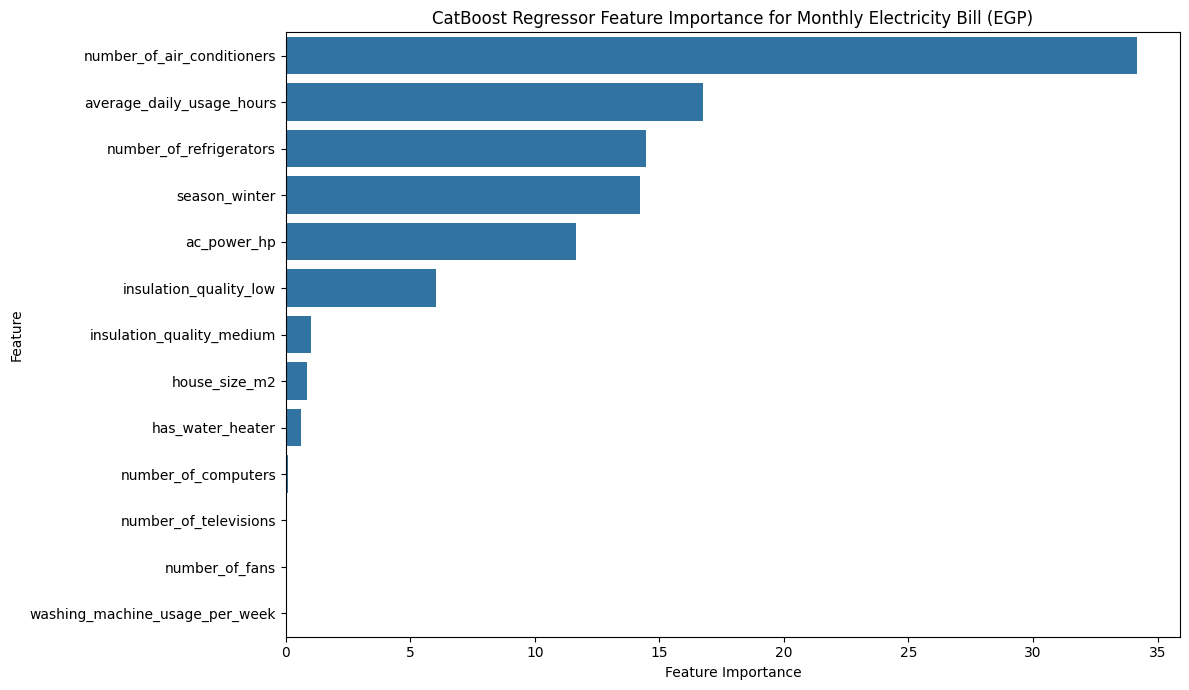

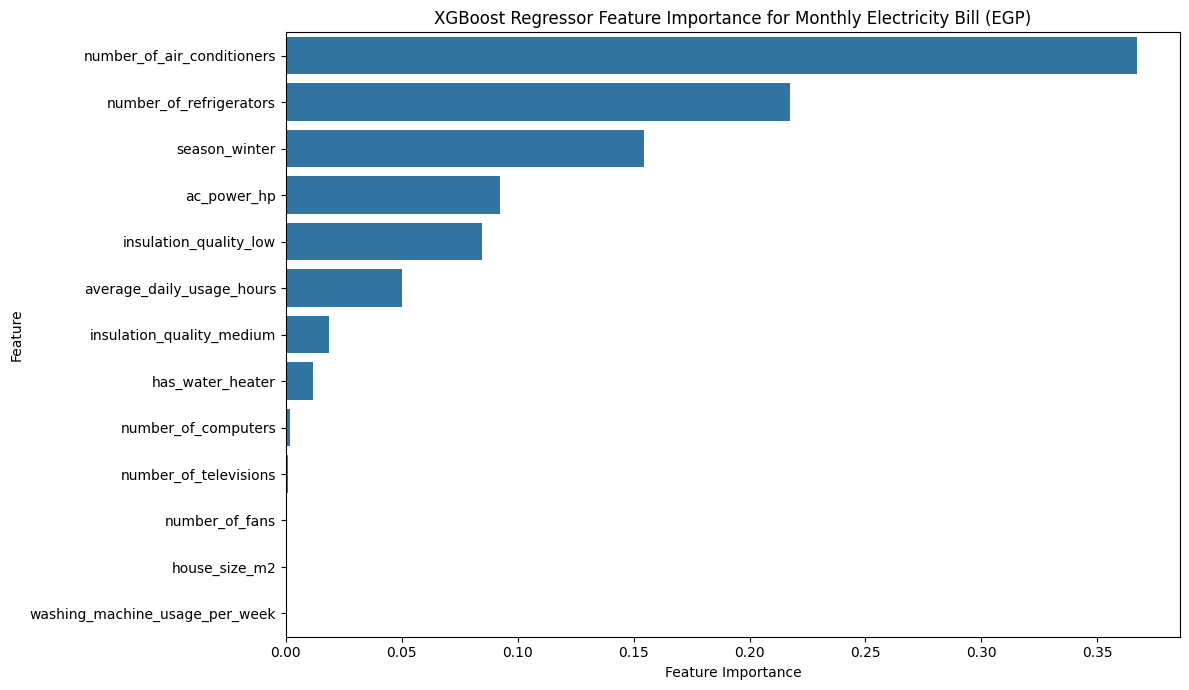

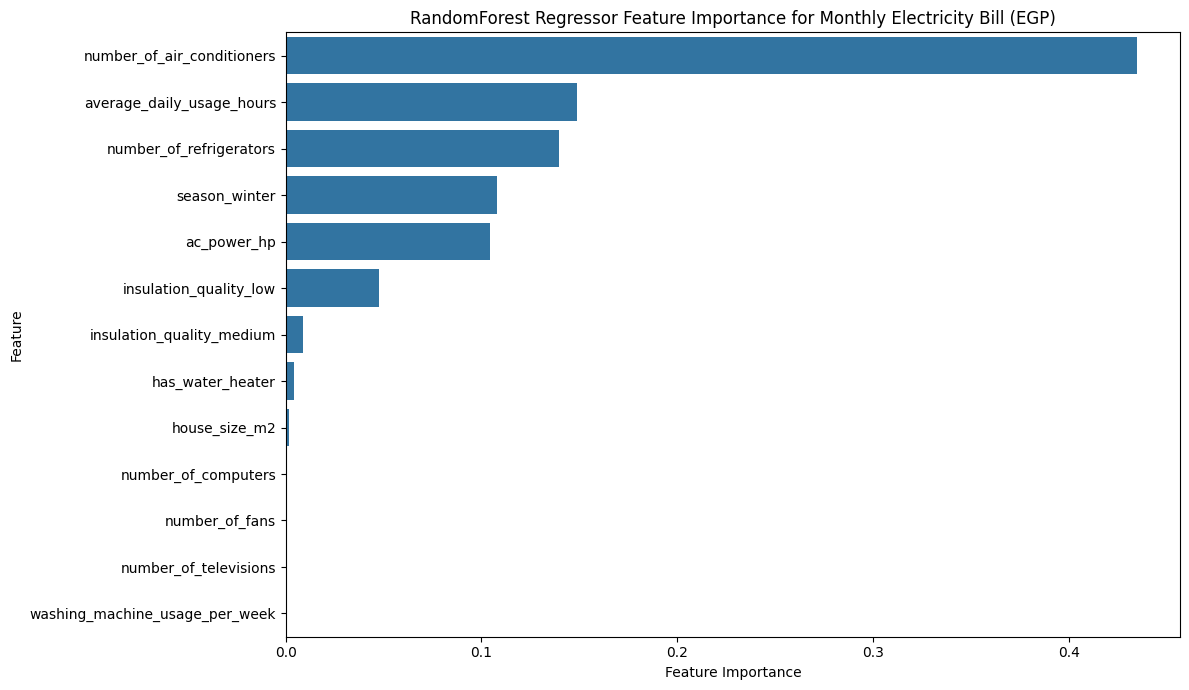

Feature importance plots for electricity bill generated.


In [ ]:
# 1. LightGBM Feature Importance (EGP)
plot_feature_importance(lgbm_model_y2, feature_names, 'LightGBM Regressor', target_name='Monthly Electricity Bill (EGP)')

# 2. CatBoost Feature Importance (EGP)
plot_feature_importance(cb_model_y2, feature_names, 'CatBoost Regressor', target_name='Monthly Electricity Bill (EGP)')

# 3. XGBoost Feature Importance (EGP)
plot_feature_importance(xgb_model_y2, feature_names, 'XGBoost Regressor', target_name='Monthly Electricity Bill (EGP)')

# 4. RandomForest Feature Importance (EGP)
plot_feature_importance(rf_model_y2, feature_names, 'RandomForest Regressor', target_name='Monthly Electricity Bill (EGP)')

print('Feature importance plots for electricity bill generated.')

In [ ]:
import joblib
import os
import tensorflow as tf # Added for Keras model saving

# Define a directory to save models
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

print(f"Saving models to directory: {model_dir}/")

# 1. Save CatBoostRegressor models
if 'cb_model_y1' in locals() and 'cb_model_y2' in locals():
    joblib.dump(cb_model_y1, os.path.join(model_dir, 'catboost_kwh_model.joblib'))
    joblib.dump(cb_model_y2, os.path.join(model_dir, 'catboost_bill_model.joblib'))
    print("CatBoostRegressor models saved successfully.")
else:
    print("Skipping CatBoostRegressor models save: 'cb_model_y1' or 'cb_model_y2' not found. Please ensure the training cells for these models have been run.")

# 2. Save Multi-Output Neural Network model
if 'multi_output_model' in locals():
    multi_output_model.save(os.path.join(model_dir, 'multi_output_nn_model.h5'))
    print("Multi-Output Neural Network model saved successfully.")
else:
    print("Skipping Multi-Output Neural Network model save: 'multi_output_model' not found. Please ensure the training cell for this model has been run.")

# 3. Save XGBoost Regressor models
if 'xgb_model_y1' in locals() and 'xgb_model_y2' in locals():
    joblib.dump(xgb_model_y1, os.path.join(model_dir, 'xgboost_kwh_model.joblib'))
    joblib.dump(xgb_model_y2, os.path.join(model_dir, 'xgboost_bill_model.joblib'))
    print("XGBoostRegressor models saved successfully.")
else:
    print("Skipping XGBoostRegressor models save: 'xgb_model_y1' or 'xgb_model_y2' not found. Please ensure the training cells for these models have been run.")

# 4. Save Multi-Output LSTM model
if 'multi_output_lstm_model' in locals():
    multi_output_lstm_model.save(os.path.join(model_dir, 'multi_output_lstm_model.h5'))
    print("Multi-Output LSTM Neural Network model saved successfully.")
else:
    print("Skipping Multi-Output LSTM Neural Network model save: 'multi_output_lstm_model' not found. Please ensure the training cell for this model has been run.")

Saving models to directory: trained_models/
CatBoostRegressor models saved successfully.
Multi-Output Neural Network model saved successfully.
XGBoostRegressor models saved successfully.
Multi-Output LSTM Neural Network model saved successfully.
